## Importando kas principales librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

## Cargando los datos pre-procesados

In [2]:
df_movies = pd.read_csv("../data/interim/movies_clean.csv", converters={"genres": json.loads})
df_ratings = pd.read_csv("../data/interim/ratings_filtered.csv")

In [6]:
print(df_movies.head())
print(df_movies.info())

   movieid                             title  \
0        1                    Toy Story 1995   
1        2                      Jumanji 1995   
2        3             Grumpier Old Men 1995   
3        4            Waiting to Exhale 1995   
4        5  Father of the Bride Part II 1995   

                                              genres  
0  [Adventure, Animation, Children, Comedy, Fantasy]  
1                     [Adventure, Children, Fantasy]  
2                                  [Comedy, Romance]  
3                           [Comedy, Drama, Romance]  
4                                           [Comedy]  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10329 entries, 0 to 10328
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieid  10329 non-null  int64 
 1   title    10329 non-null  object
 2   genres   10329 non-null  object
dtypes: int64(1), object(2)
memory usage: 242.2+ KB
None


In [7]:
print(df_ratings.head())
print(df_ratings.info())

   userId  movieId  rating   timestamp
0     244     1940     4.0   953171000
1     627      529     4.0  1237932833
2     584      337     4.0   944925912
3     363     1247     4.0   947643674
4     469     1080     4.0   865534729
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17575 entries, 0 to 17574
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userId     17575 non-null  int64  
 1   movieId    17575 non-null  int64  
 2   rating     17575 non-null  float64
 3   timestamp  17575 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 549.3 KB
None


### Géneros únicos identificados

In [8]:
pd.Series([genero for lista_genero in df_movies["genres"] for genero in lista_genero]).unique()

array(['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy',
       'Romance', 'Drama', 'Action', 'Crime', 'Thriller', 'Horror',
       'Mystery', 'Sci-Fi', 'IMAX', 'War', 'Musical', 'Documentary',
       'Western', 'Film-Noir', '(no genres listed)'], dtype=object)

### Uniendo el dataframe de puntajes (ratings) con el dataframe de películas (movies)

In [9]:
ratings_movies_merge = pd.merge(df_ratings, df_movies, right_on="movieid", left_on="movieId", how="inner")
ratings_movies_merge = ratings_movies_merge[["userId", "movieId", "title", "rating", "genres"]]
print(ratings_movies_merge.head())

   userId  movieId                             title  rating  \
0     244     1940         Gentlemans Agreement 1947     4.0   
1     627      529  Searching for Bobby Fischer 1993     4.0   
2     584      337   Whats Eating Gilbert Grape 1993     4.0   
3     363     1247                 Graduate The 1967     4.0   
4     469     1080  Monty Pythons Life of Brian 1979     4.0   

                     genres  
0                   [Drama]  
1                   [Drama]  
2                   [Drama]  
3  [Comedy, Drama, Romance]  
4                  [Comedy]  


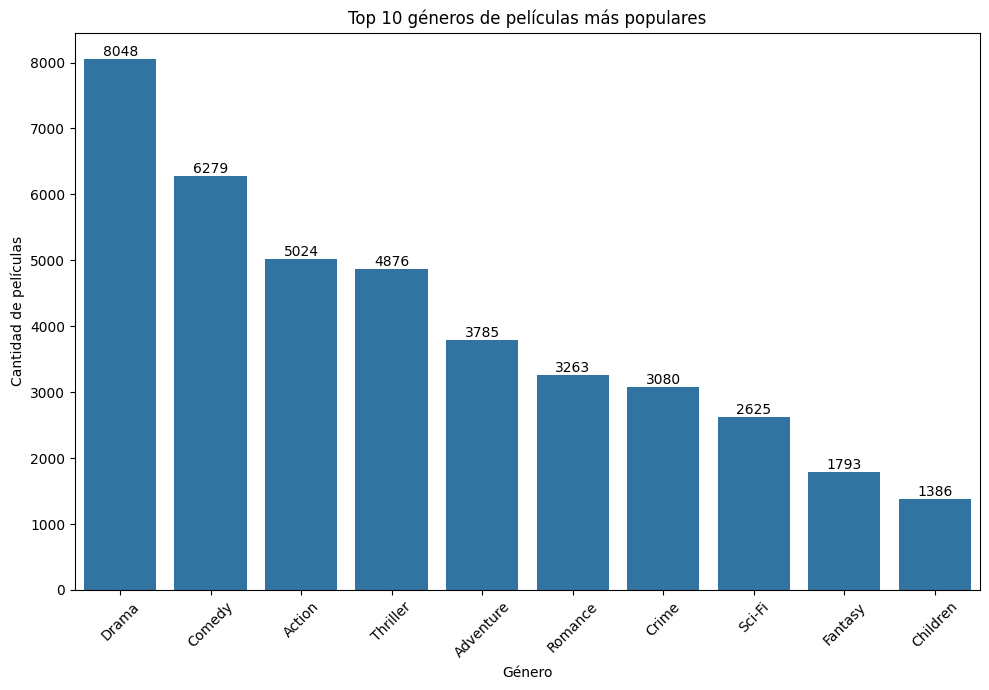

In [10]:
generos_peliculas = pd.Series([genero for lista_genero in ratings_movies_merge["genres"] for genero in lista_genero])
top_generos = generos_peliculas.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 7))
graf = sns.barplot(x=top_generos.index, y=top_generos.values, ax=ax)
for i in graf.containers:
    graf.bar_label(i)
plt.xticks(rotation=45)
plt.title("Top 10 géneros de películas más populares")
plt.xlabel("Género")
plt.ylabel("Cantidad de películas")
plt.tight_layout()
plt.show()

### Filtrando las películas que no cuentan con un género de película establecida

In [11]:
ratings_genres = ratings_movies_merge[ratings_movies_merge["genres"].apply(lambda x: "(no genres listed)" not in x)]
print(ratings_genres.head())

   userId  movieId                             title  rating  \
0     244     1940         Gentlemans Agreement 1947     4.0   
1     627      529  Searching for Bobby Fischer 1993     4.0   
2     584      337   Whats Eating Gilbert Grape 1993     4.0   
3     363     1247                 Graduate The 1967     4.0   
4     469     1080  Monty Pythons Life of Brian 1979     4.0   

                     genres  
0                   [Drama]  
1                   [Drama]  
2                   [Drama]  
3  [Comedy, Drama, Romance]  
4                  [Comedy]  


## Análisis de los datos

### Promedio de puntaje (rating) por película

In [14]:
top_movies_public = ratings_genres.groupby("title")["rating"].mean().reset_index().sort_values(by="rating", ascending=False).head(10)
print(top_movies_public.head())

                                     title  rating
3860            Somethings Gotta Give 2003     5.0
597                  Boys on the Side 1995     5.0
3664  Secret Life of Walter Mitty The 2013     5.0
65            8 Heads in a Duffel Bag 1997     5.0
7                    12 Years a Slave 2013     5.0


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
from nltk.tokenize import wordpunct_tokenize
import nltk
# nltk.download('punkt')
# nltk.download('stopwords')

titulos = con_genero["title"]
#tokenizar los titulos (aplicado individualmente a cada título)
tokens_titulos = titulos.apply(wordpunct_tokenize)
# obteniendo la lista de stopwords en ingles
stop_words = set(stopwords.words('english'))
# filtrando los stopwords de cada título tokenizado
filtered_titles = tokens_titulos.apply(
    lambda token_titulo: " ".join([word for word in token_titulo if word.lower() not in stop_words])
)
filtered_titles.head()

0          Gentlemans Agreement 1947
1       Searching Bobby Fischer 1993
2    Whats Eating Gilbert Grape 1993
3                      Graduate 1967
4      Monty Pythons Life Brian 1979
Name: title, dtype: object

In [18]:
import re
def clean_title(title):
    return re.sub("[^a-zA-Z0-9 ]", "", title)

In [ ]:
import numpy as np

vectorizer = TfidfVectorizer(ngram_range=(1, 2))
vectorizer_titles = vectorizer.fit_transform(filtered_titles)

def busqueda_titulo(titulo):
    titulo = clean_title(titulo)
    query_title = vectorizer.transform([titulo])
    similitud = cosine_similarity(vectorizer_titles, query_title).flatten()
    indices = np.argpartition(similitud, -5)[-5:]
    resultados = con_genero.iloc[indices][::-1]
    return resultados

In [24]:
resultados_peliculas = busqueda_titulo("father")
print(resultados_peliculas["title"].reset_index(drop=True))

0    In the Name of the Father 1993
1    In the Name of the Father 1993
2    In the Name of the Father 1993
3    In the Name of the Father 1993
4    In the Name of the Father 1993
Name: title, dtype: object
